I am only cleaning and discovering data because I am going to analyis it using PowerBI

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amritanshukush/adverse-drug-reaction-adr-reporting/synthetic_drug_data.csv


In [13]:
df = pd.read_csv("/kaggle/input/datasets/amritanshukush/adverse-drug-reaction-adr-reporting/synthetic_drug_data.csv")
df.head()

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,NaN,10019211,mild,5
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,NaN,10016256,mild,3
3,REP-vzYm2NEH,72,Female,Prednisone,46mg,29,"Metformin, Lisinopril",10013968,mild,6
4,REP-WWcINmT6,56,Male,Atorvastatin,936mg,28,NaN,10037660,mild,9


In [14]:
df.size

10000000

In [15]:
df.dtypes

ReportID            object
PatientAge           int64
Gender              object
DrugName            object
Dosage              object
DurationDays         int64
ConcomitantDrugs    object
ADR_Code             int64
Seriousness         object
OnsetDays            int64
dtype: object

#  Converting the dosage to a numeric data 

In [16]:
df['Dosage'] = df['Dosage'].str.replace('mg', '')

 #Convert the column type from string (object) to integer
df['Dosage'] = df['Dosage'].astype(int)

 #Rename the column to include the unit
df = df.rename(columns={'Dosage': 'Dosage_mg'})

# Missing Data

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

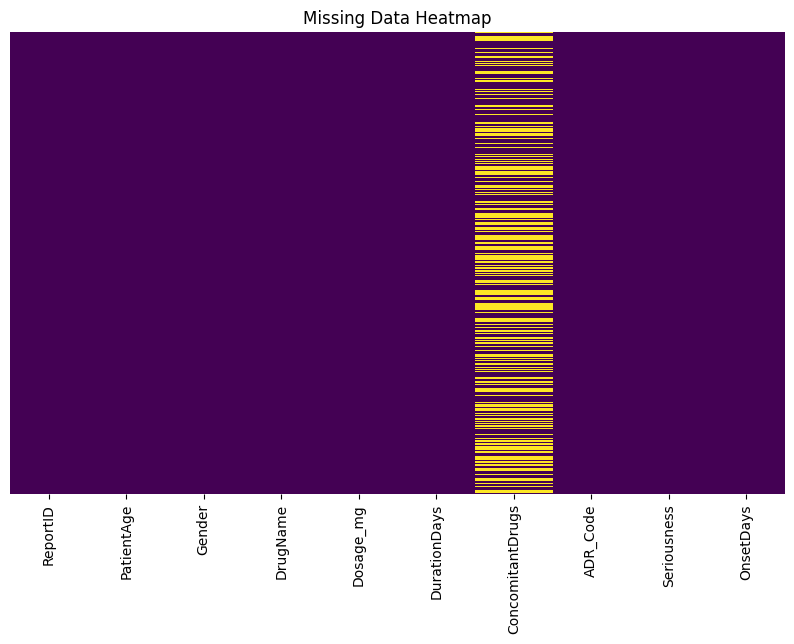

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

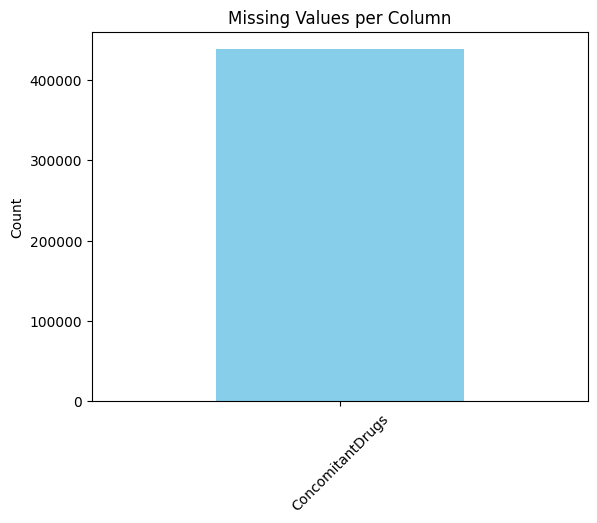

In [19]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0].plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Calculate the percentage of missing values
missing_percentage = df['ConcomitantDrugs'].isnull().mean() * 100

print(f"Percentage of missing data in ConcomitantDrugs: {missing_percentage}%")

Percentage of missing data in ConcomitantDrugs: 43.7828%


In [21]:
df['ConcomitantDrugs'] = df['ConcomitantDrugs'].fillna('none')

#  Outliers 

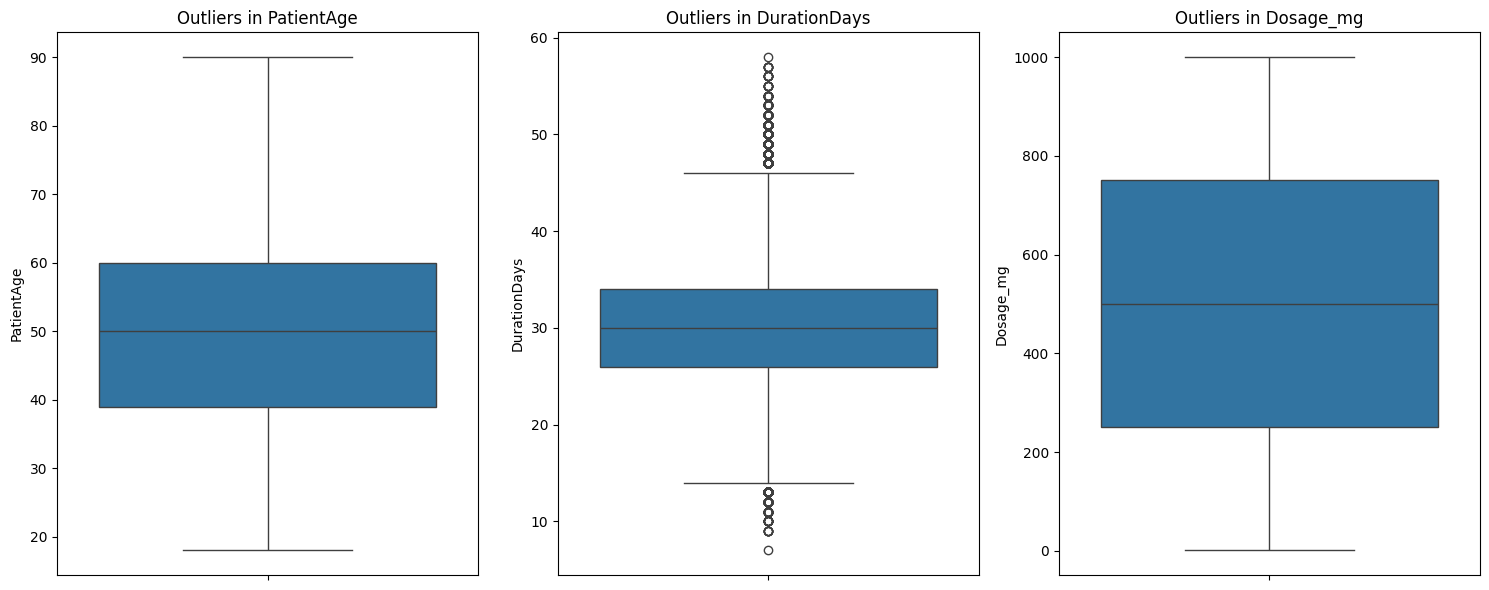

In [25]:

cols = ['PatientAge', 'DurationDays', 'Dosage_mg']


plt.figure(figsize=(15, 6))

for i, col in enumerate(cols):
    plt.subplot(1, 3, i + 1)
    
    sns.boxplot(y=df[col])
    #sns.stripplot(y=df[col], color='red', alpha=0.5) 
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

As we can see the outliers in duration days , which may mean that it is rare for the patients to experiance reactions in short or long time intervals; so this doesn't mean we have to exclude them from our data 


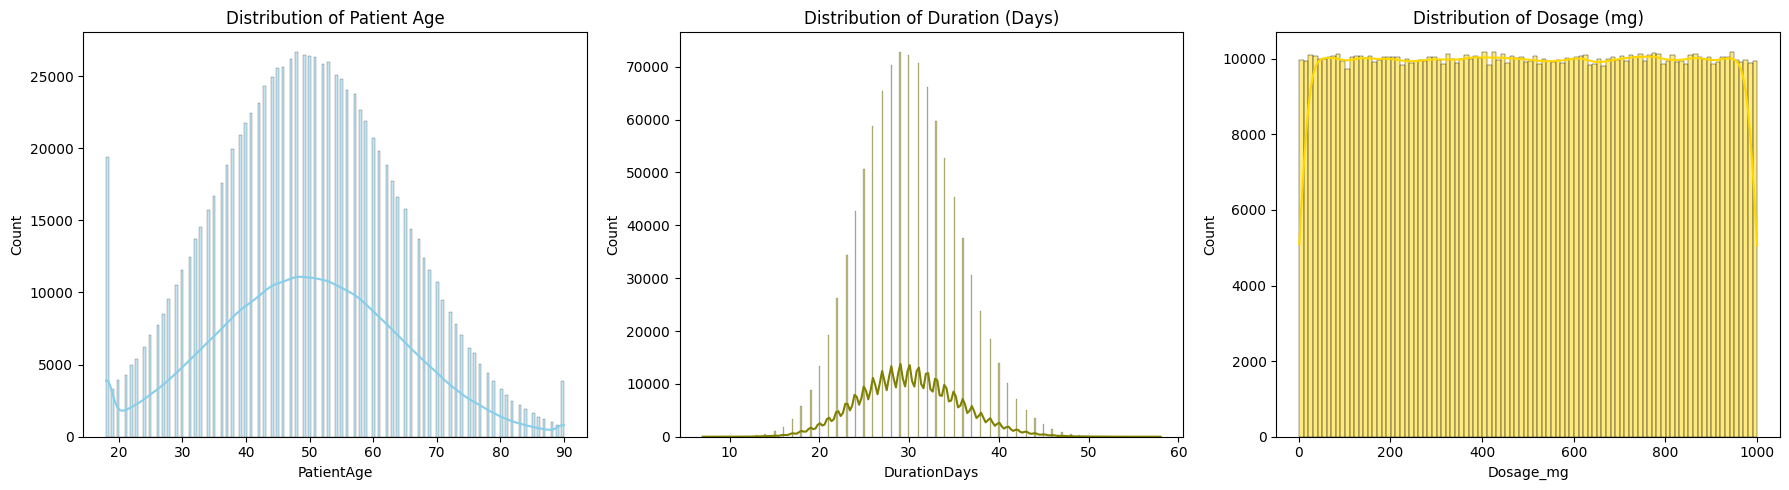

In [28]:
# 3. Create a layout for 3 plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot PatientAge Distribution
sns.histplot(df['PatientAge'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Patient Age')

# Plot DurationDays Distribution
sns.histplot(df['DurationDays'], kde=True, color='olive', ax=axes[1])
axes[1].set_title('Distribution of Duration (Days)')

# Plot Dosage_mg Distribution
sns.histplot(df['Dosage_mg'], kde=True, color='gold', ax=axes[2])
axes[2].set_title('Distribution of Dosage (mg)')

plt.tight_layout()
plt.show()

As we can see the dosage isn't a normal distribution 

In [29]:
print(df['Dosage_mg'].describe())

count    1000000.000000
mean         500.396800
std          288.690515
min            1.000000
25%          250.000000
50%          500.000000
75%          751.000000
max         1000.000000
Name: Dosage_mg, dtype: float64


According to the stats for the dosage we can confirm it is actuelly a uniform data 

$$\mu = \frac{a + b}{2}$$


$$\sigma = \sqrt{\frac{(b - a)^2}{12}}$$